In [1]:
# import Providentia
import providentia as prv

In [2]:
# magic to make plots appear inline
%matplotlib inline

# Initialise object

In [3]:
# initialise object
provi = prv.Providentia('library.conf', subsection='LOCAL·Spain')

# Load data

In [4]:
# read and filter data from .conf (keeping stations only in Spain)
# assuming that the data was downloaded on tutorial 0
provi.load()


Updating file tree /Users/denebowdalo/provi_master/settings/internal/ghost_filetree_1.5.json...
Updating file tree /Users/denebowdalo/provi_master/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - EBAS-EMEP|sconco3
MODELS
 - cams_reanalysis_ensemble_validated-regional-000 (CAMS)
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data


# Show configuration

In [5]:
# print .conf
provi.print_config()

[LOCAL]
network = EBAS-EMEP
species = sconco3
resolution = hourly
start_date = 20180101
end_date = 20180201
model = cams_reanalysis_ensemble_validated-regional-000 (CAMS)
observations_data_label = OBS
temporal_colocation = True
spatial_colocation = False
plots = debug
report_summary = True
report_stations = False
report_title = Providentia Report
report_filename = local
statistic_mode = Temporal|Spatial
statistic_aggregation = Median
periodic_statistic_mode = Independent
periodic_statistic_aggregation = Median
timeseries_statistic_aggregation = Median
harmonise_summary = False
map_extent = -25, 42, 32, 72
dl_interpolated = False
dl_mode = both
dl_ghost_source = zenodo

    [[All]]

    [[France]]
    country = keep: France ||

    [[Germany]]
    country = keep: Germany ||
  
    [[Spain]]
    country = keep: Spain ||

    [[UK]]
    country = keep: United Kingdom ||


In [6]:
# alternative way of printing active config file
print(provi)

[LOCAL]
network = EBAS-EMEP
species = sconco3
resolution = hourly
start_date = 20180101
end_date = 20180201
model = cams_reanalysis_ensemble_validated-regional-000 (CAMS)
observations_data_label = OBS
temporal_colocation = True
spatial_colocation = False
plots = debug
report_summary = True
report_stations = False
report_title = Providentia Report
report_filename = local
statistic_mode = Temporal|Spatial
statistic_aggregation = Median
periodic_statistic_mode = Independent
periodic_statistic_aggregation = Median
timeseries_statistic_aggregation = Median
harmonise_summary = False
map_extent = -25, 42, 32, 72
dl_interpolated = False
dl_mode = both
dl_ghost_source = zenodo

    [[All]]

    [[France]]
    country = keep: France ||

    [[Germany]]
    country = keep: Germany ||
  
    [[Spain]]
    country = keep: Spain ||

    [[UK]]
    country = keep: United Kingdom ||



# Save configuration and data

## Save configuration

In [7]:
provi.save(format='conf')

Data saved to /Users/denebowdalo/provi_master/saved_data/PRV_20260917_2237.conf


## Save data to netCDF

In [8]:
provi.save(format='nc')

Data saved to /Users/denebowdalo/provi_master/saved_data/PRV_20260917_2237.nc


## Save data to numpy

In [9]:
provi.save(format='np')

Data saved to /Users/denebowdalo/provi_master/saved_data/PRV_20260917_2237.npz


# Get data in memory

In [10]:
# return data in memory (in Xarray format)
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 230kB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 13,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 77kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 116kB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 1kB ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 1kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

In [11]:
# return specific variable in memory (as numpy array)
latitude_var = provi.variable('EBAS-EMEP|sconco3_latitude')
latitude_var

masked_array(
  data=[[39.54694],
        [42.72056],
        [39.87528],
        [37.23722],
        [43.43917],
        [41.27417],
        [42.31917],
        [38.47278],
        [39.08278],
        [41.23889],
        [41.39389],
        [42.63472],
        [37.05194]],
  mask=False,
  fill_value=1e+20)

# Calculate statistics

In [12]:
# calculate and return statistics
stat = provi.statistic('r', labela='OBS', labelb='CAMS', per_station=True)
stat

array([[0.7662163 , 0.75738888, 0.87161918, 0.44496306, 0.86327536,
        0.90116959, 0.84386778, 0.91355175, 0.74624945, 0.8288355 ,
        0.85651742, 0.8029561 , 0.93175369]])

# Filter by metadata

## By station

In [13]:
# filter data for multiple specific stations
provi.reset()
provi.filter_station(['AT0002R_UVP','SK0007R_UVP'])
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 41kB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 2,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 12kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 18kB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 24B ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 24B ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 24B ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 176B ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U3 24B ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 168B ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

## By country

In [14]:
# filter data by country metadata 
provi.reset()
provi.filter('country', keep=['France','United Kingdom'])
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 534kB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 30,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 179kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 268kB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 360B ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 360B ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 360B ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 3kB ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U13 2kB ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 3kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

## By altitude

In [15]:
# filter data by station altitude
provi.reset()
provi.filter('altitude', lower=500)
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 837kB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 47,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 280kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 420kB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 564B ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 564B ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 564B ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 4kB ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U14 3kB ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 4kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

## By daytime

In [16]:
# filter data by period
provi.reset()
provi.filter('period', keep='Daytime')
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 2MB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 131,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 780kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 1MB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 2kB ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 2kB ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 2kB ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 12kB ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U14 7kB ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 11kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

## By data coverage

In [17]:
# filter data by total data coverage
provi.reset()
provi.filter('total_coverage', limit=50)
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 2MB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 129,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 768kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 1MB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 2kB ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 2kB ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 2kB ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 11kB ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U14 7kB ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 11kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

# Reset filter

In [18]:
# reset filter how it was when class was initialised, i.e. Spanish stations again
provi.reset(initialise=True)
stations_data = provi.data(format='xr')
stations_data

Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data


<xarray.Dataset> Size: 230kB
Dimensions:                                                                             (
                                                                                         data_label: 2,
                                                                                         ghost_data_variable: 3,
                                                                                         station_EBAS-EMEP|sconco3: 13,
                                                                                         time: 744,
                                                                                         qa: 79,
                                                                                         flag: 188,
                                                                                         month: 1)
Coordinates:
  * time                                                                                (time) datetime64[ns] 6kB ...
Dimensions without coordinates: data_label, ghost_data_variable,
                                station_EBAS-EMEP|sconco3, qa, flag, month
Data variables: (12/64)
    data_labels                                                                         (data_label) <U4 32B ...
    ghost_data_variables                                                                (ghost_data_variable) <U20 240B ...
    EBAS-EMEP|sconco3_data                                                              (data_label, station_EBAS-EMEP|sconco3, time) float32 77kB ...
    EBAS-EMEP|sconco3_ghost_data                                                        (ghost_data_variable, station_EBAS-EMEP|sconco3, time) float32 116kB ...
    EBAS-EMEP|sconco3_qa                                                                (qa) float32 316B ...
    EBAS-EMEP|sconco3_flags                                                             (flag) float32 752B ...
    ...                                                                                  ...
    EBAS-EMEP|sconco3_primary_sampling_instrument_name                                  (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_sample_preparation_types                                          (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_sample_preparation_techniques                                     (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_measurement_methodology                                           (station_EBAS-EMEP|sconco3, month) <U22 1kB ...
    EBAS-EMEP|sconco3_measuring_instrument_name                                         (station_EBAS-EMEP|sconco3, month) <U3 156B ...
    EBAS-EMEP|sconco3_measuring_instrument_sampling_type                                (station_EBAS-EMEP|sconco3, month) <U21 1kB ...
Attributes:
    title:         Saved data from Providentia
    institution:   Barcelona Supercomputing Center
    source:        Providentia
    data_version:  1.5

# Make plots

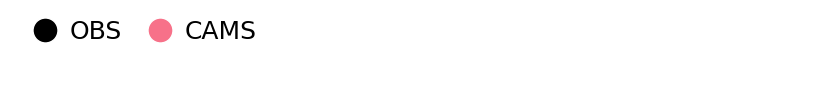

In [19]:
# make a legend plot
provi.plot('legend')

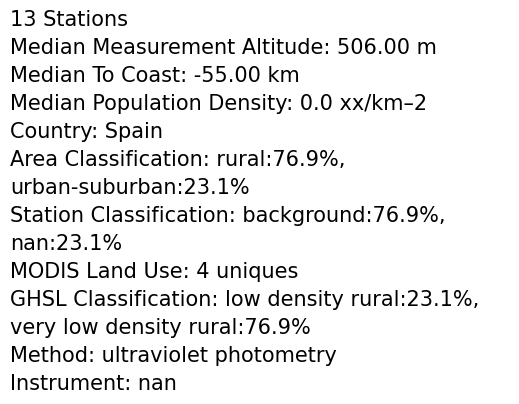

In [20]:
# make a metadata plot
provi.plot('metadata')

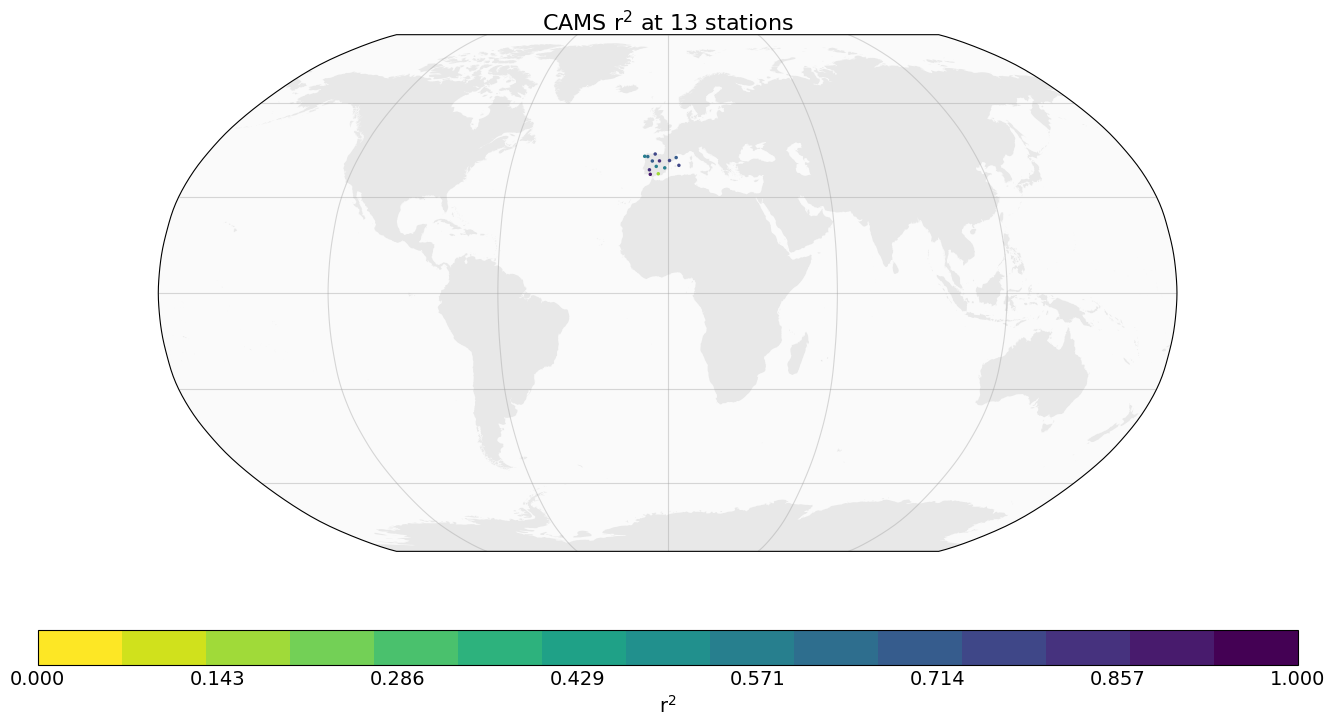

In [21]:
# make a map plot (r2 statistic)
provi.plot('map-r2', labela='OBS', labelb='CAMS', map_extent=[-180, 180, -90, 90])

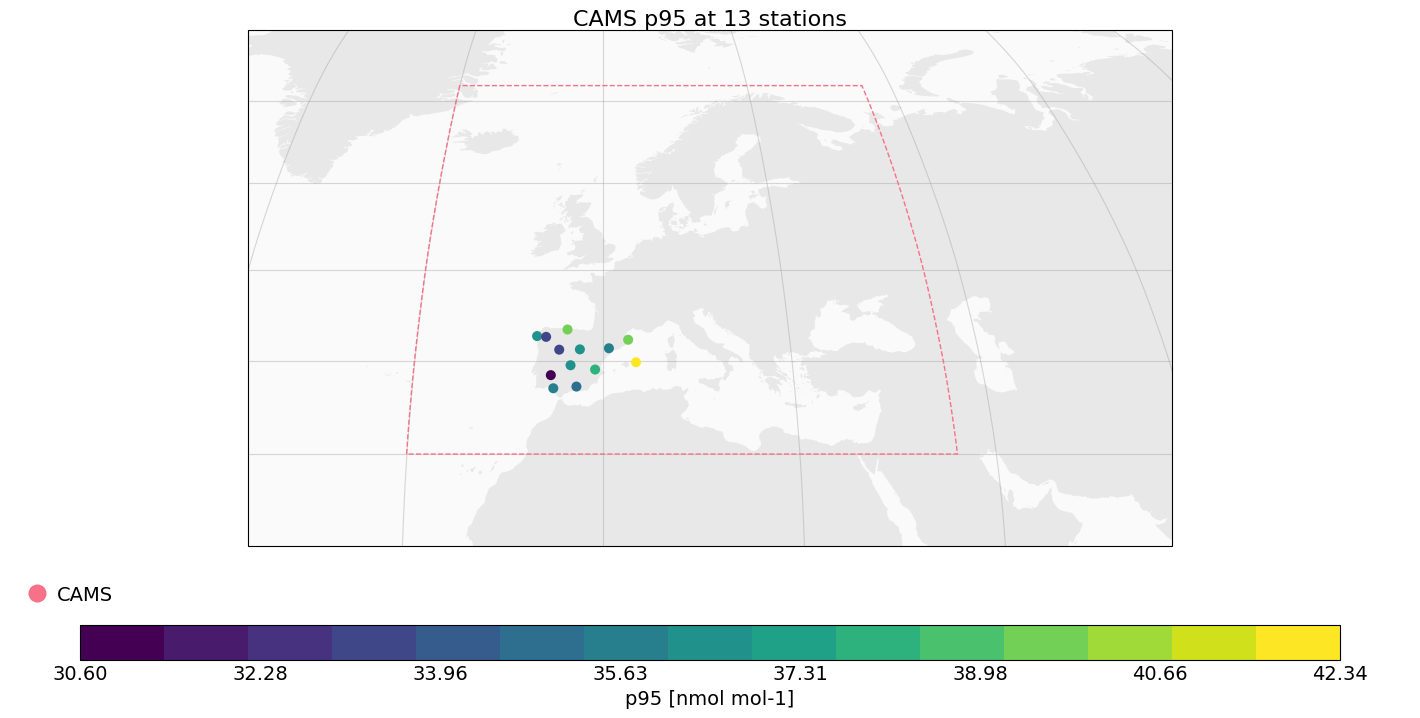

In [22]:
# make a map plot (p95 statistic)
provi.plot('map-p95', labela='CAMS', map_extent=[-50, 80, 20, 80], plot_options=['domain'])

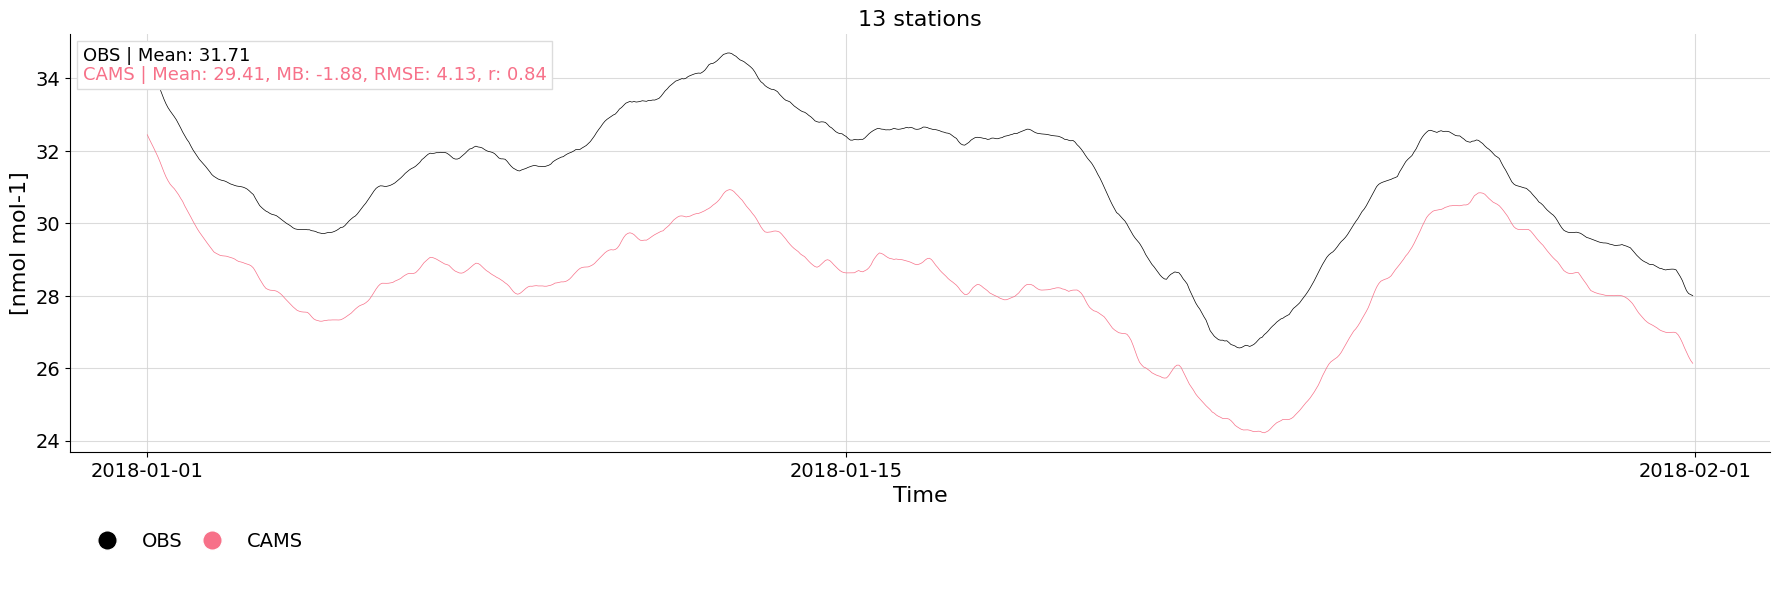

In [23]:
# make a timeseries plot
provi.plot('timeseries', annotate=True, smooth=100, hidedata=True)

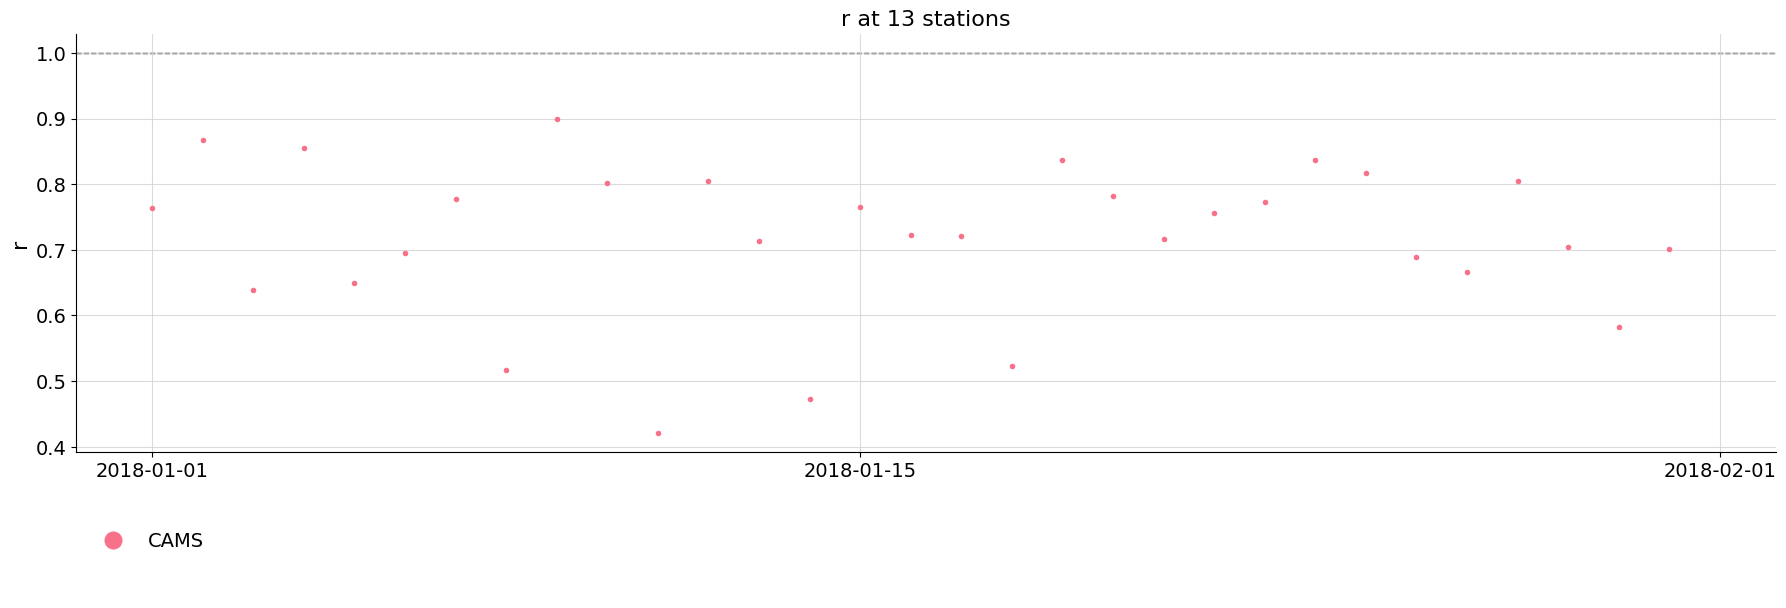

In [24]:
# make a statistical timeseries of r 
provi.plot('timeseries-r-daily')

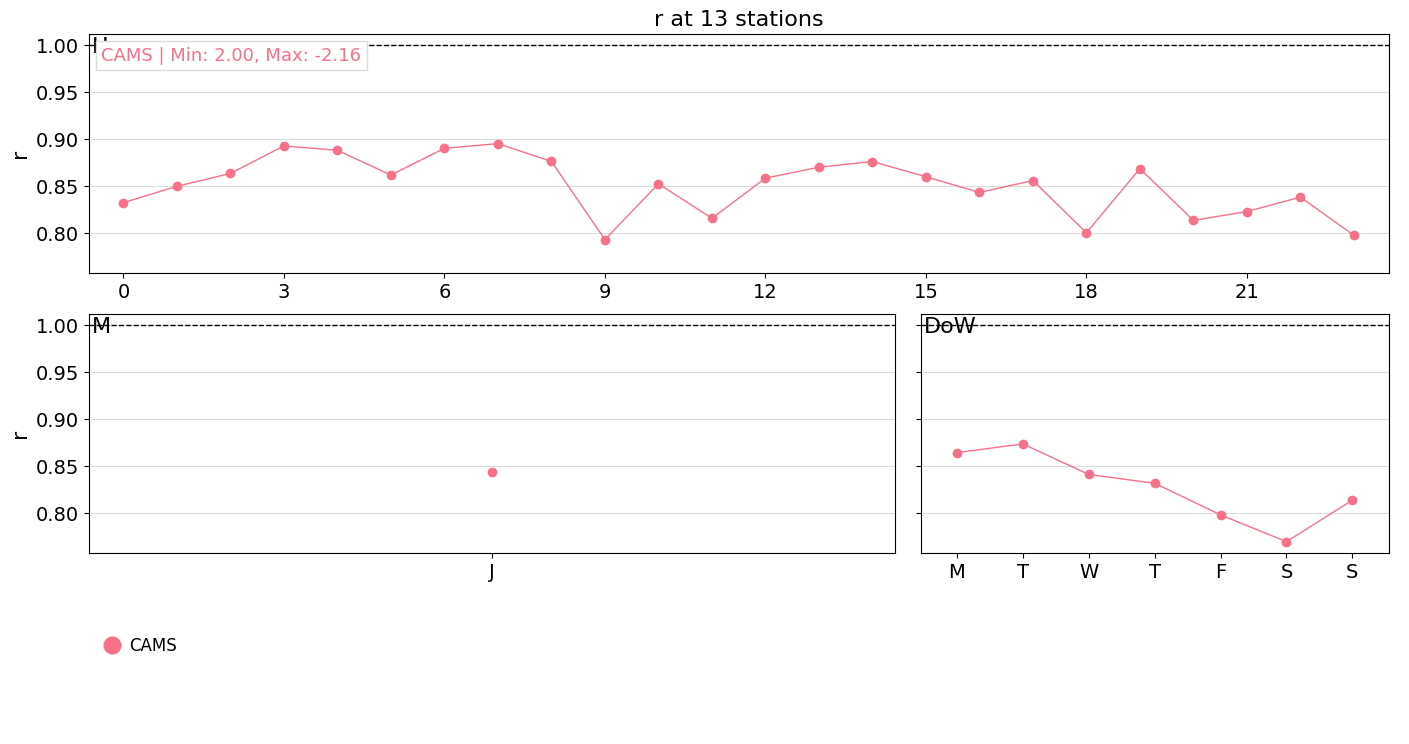

In [25]:
# make a periodic plot (r statistic)
provi.plot('periodic-r', plot_options=['annotate'])

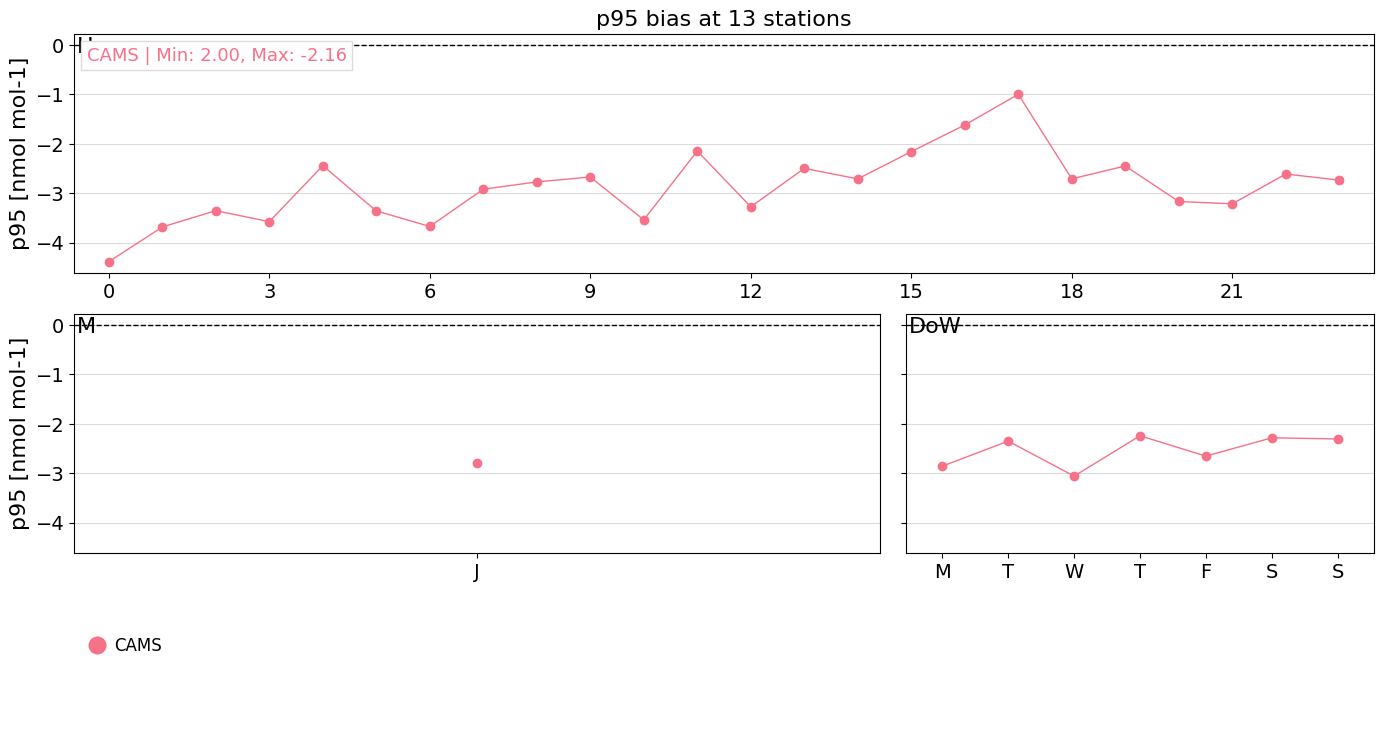

In [26]:
# make a periodic plot (p95 statistic)
provi.plot('periodic-p95', plot_options=['annotate','bias'])

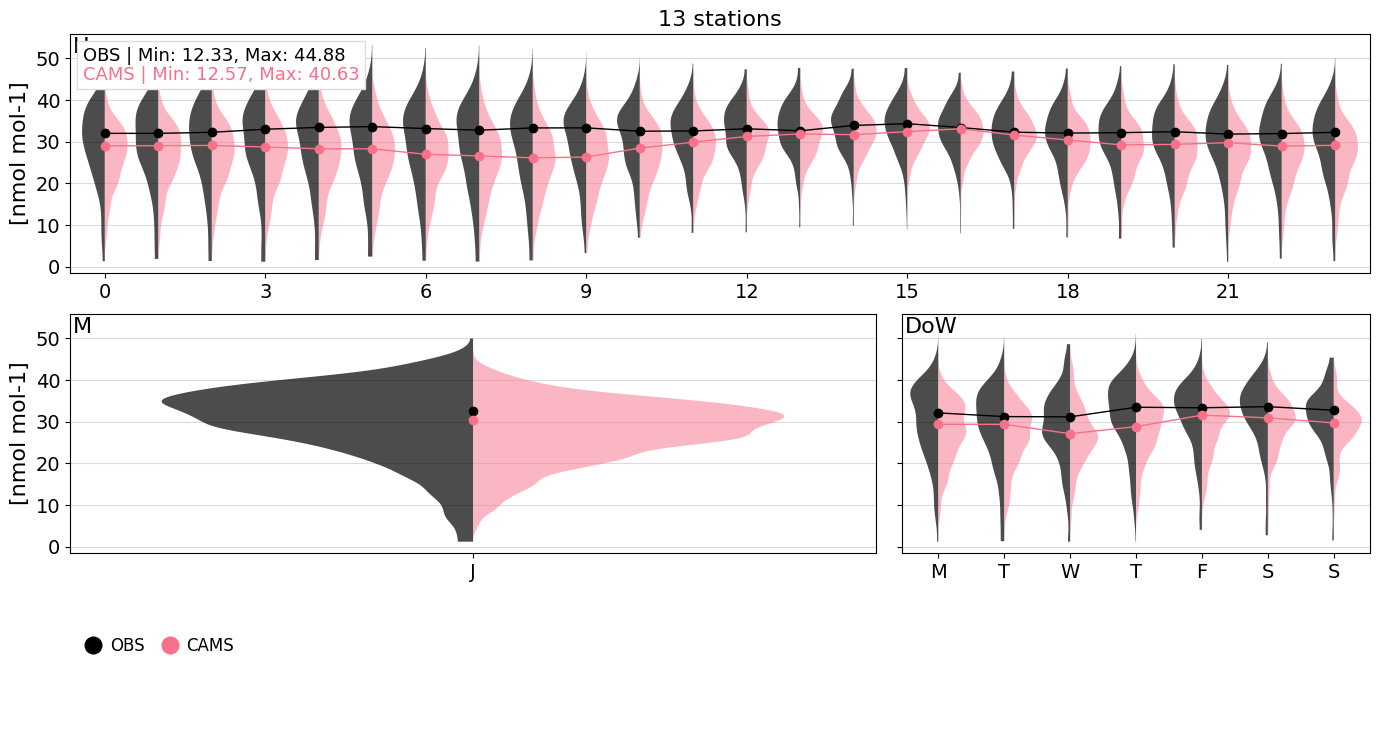

In [27]:
# make a periodic-violin plot
provi.plot('periodic-violin', plot_options=['annotate'])

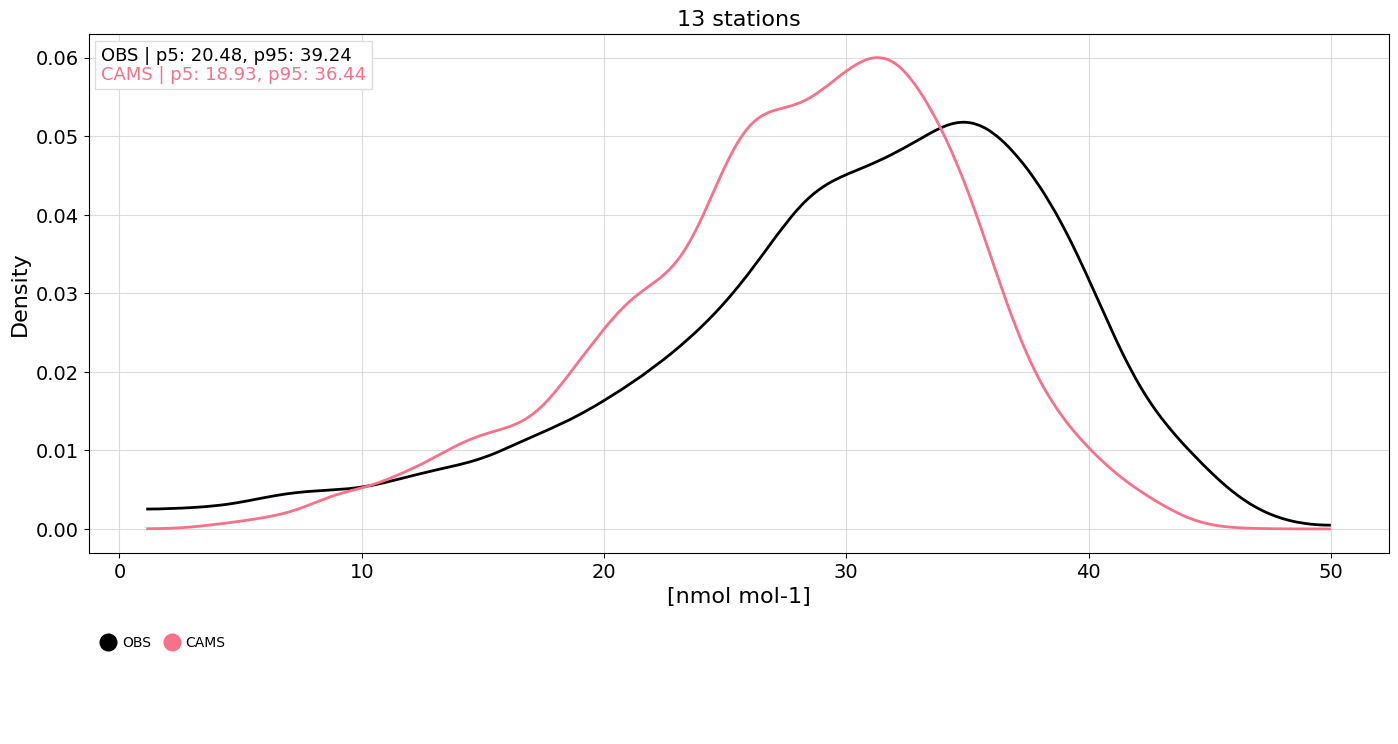

In [28]:
# make a distribution plot
provi.plot('distribution', annotate=['p5','p95'])

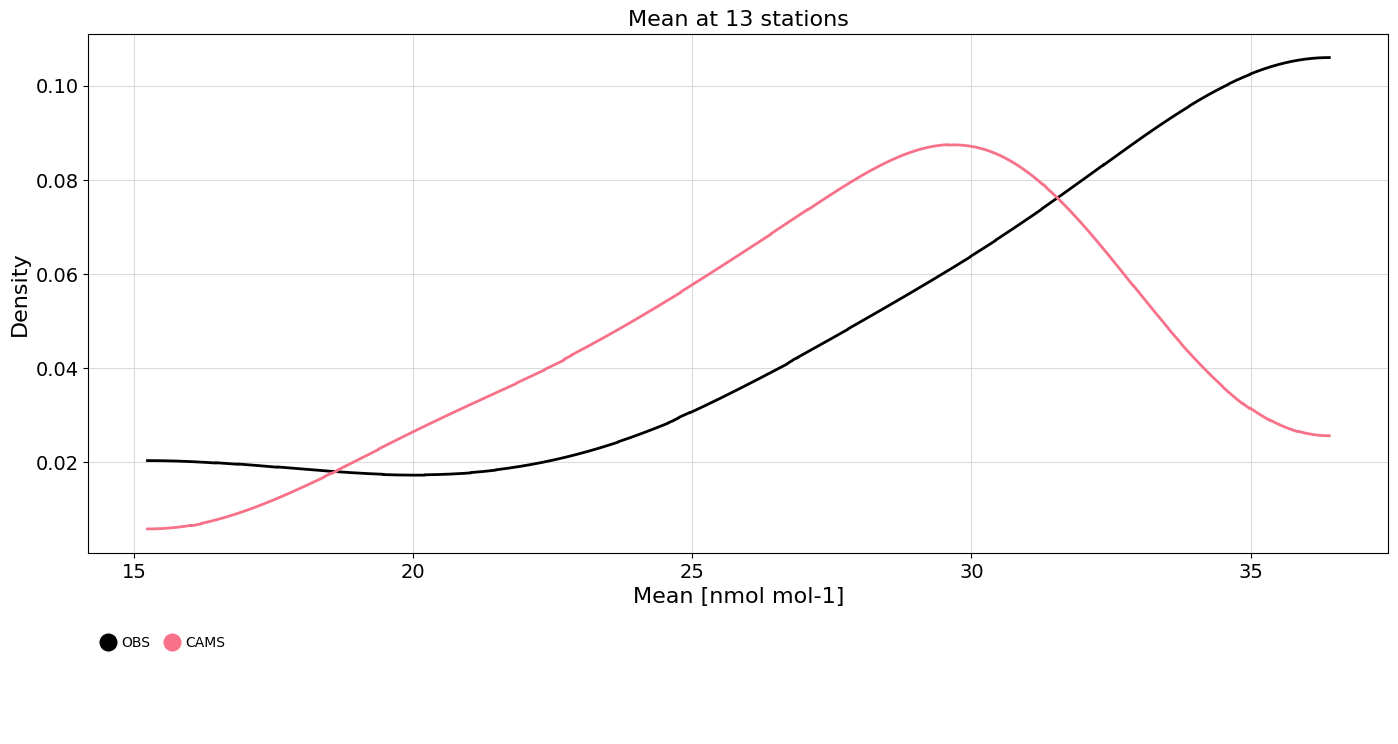

In [29]:
# make a distribution plot of station means
provi.plot('distribution-Mean')

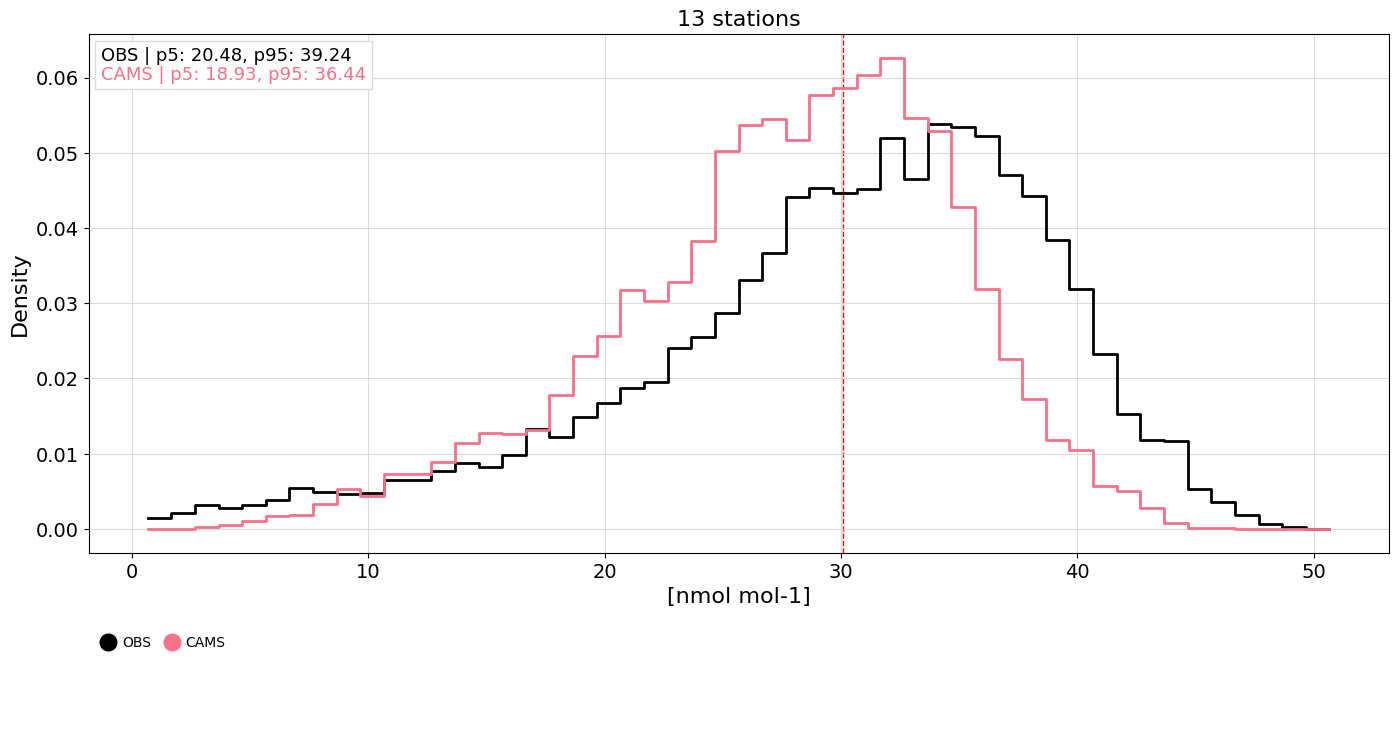

In [30]:
# make a histogram plot
provi.plot('histogram', annotate=['p5','p95'],threshold=True)

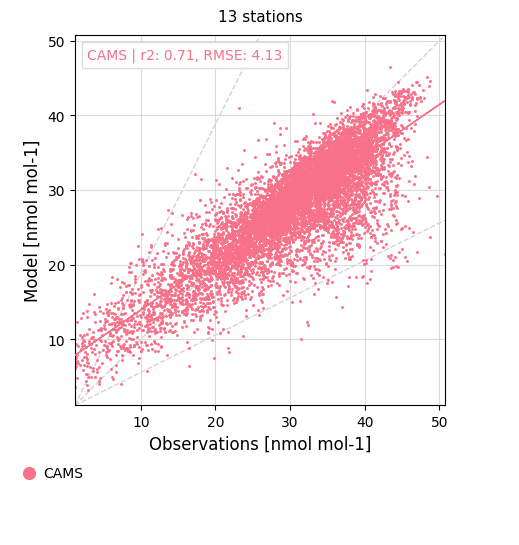

In [32]:
# make a scatter plot
provi.plot('scatter', plot_options=['annotate','regression'])

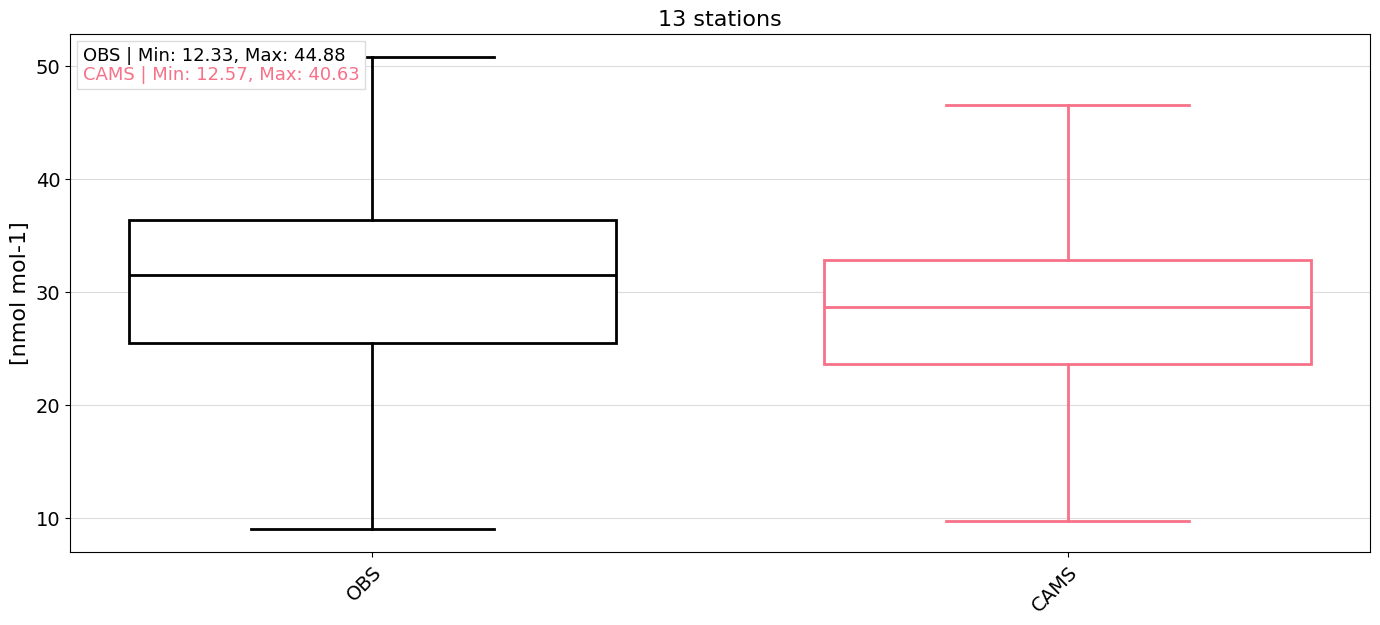

In [33]:
# make a boxplot
provi.plot('boxplot', plot_options=['annotate'])

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data


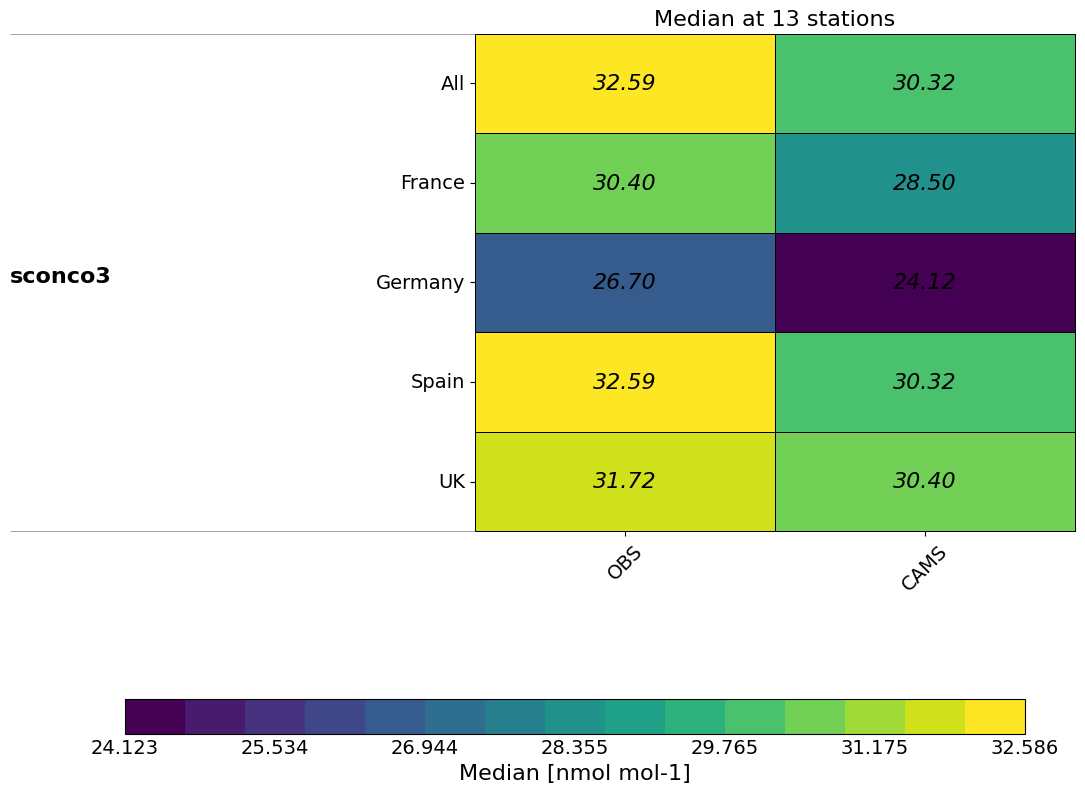

In [34]:
# make a heatmap (Median stat)
provi.plot('heatmap-Median', annotate=True, multispecies=True)

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data


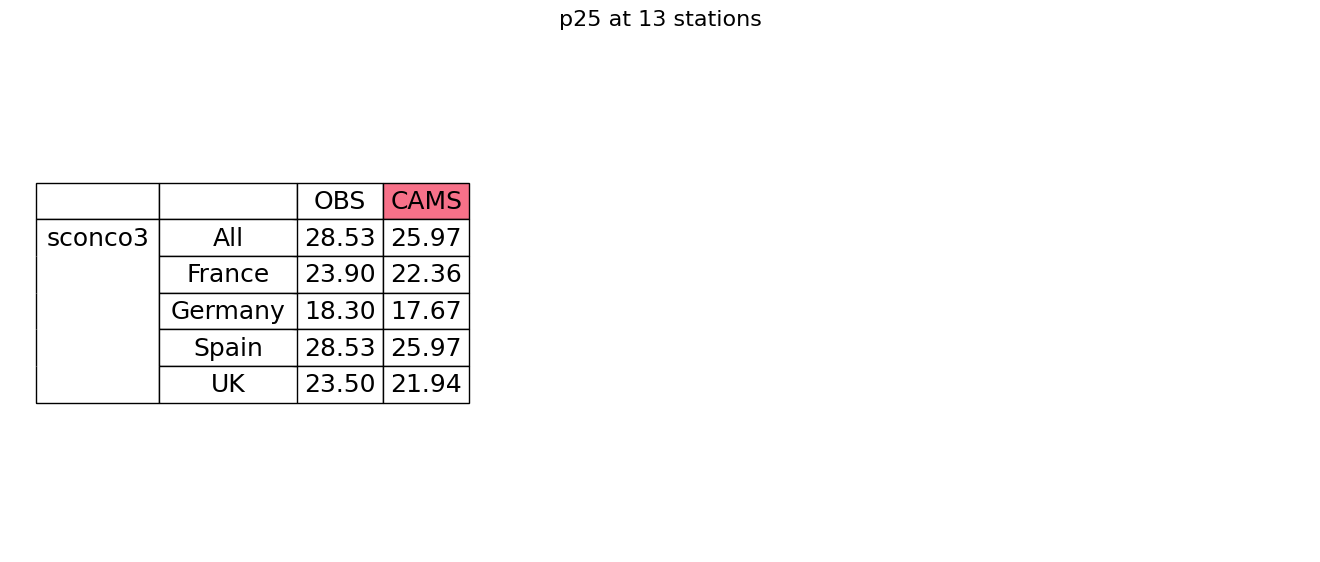

In [35]:
# make a table (p25 stat)
provi.plot('table-p25', multispecies=True)

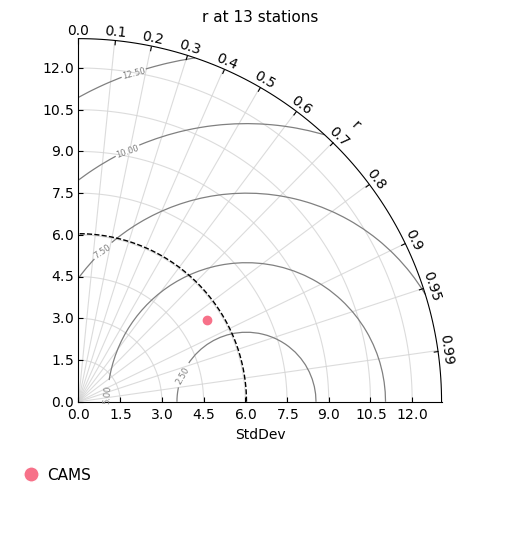

In [36]:
# make a Taylor diagram
provi.plot('taylor')

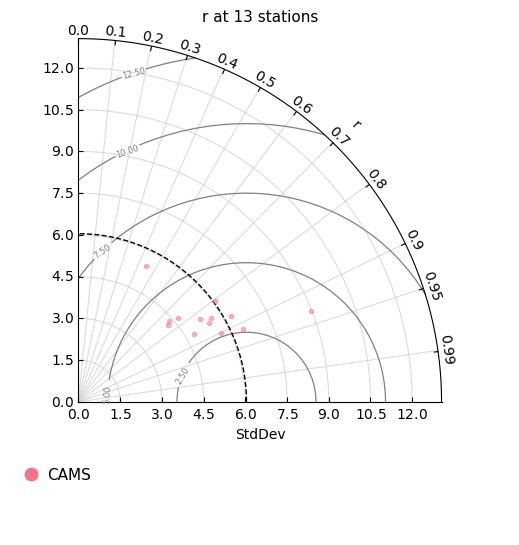

In [37]:
# make a Taylor diagram (per station)
provi.plot('taylor-r', perstation=True)

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data


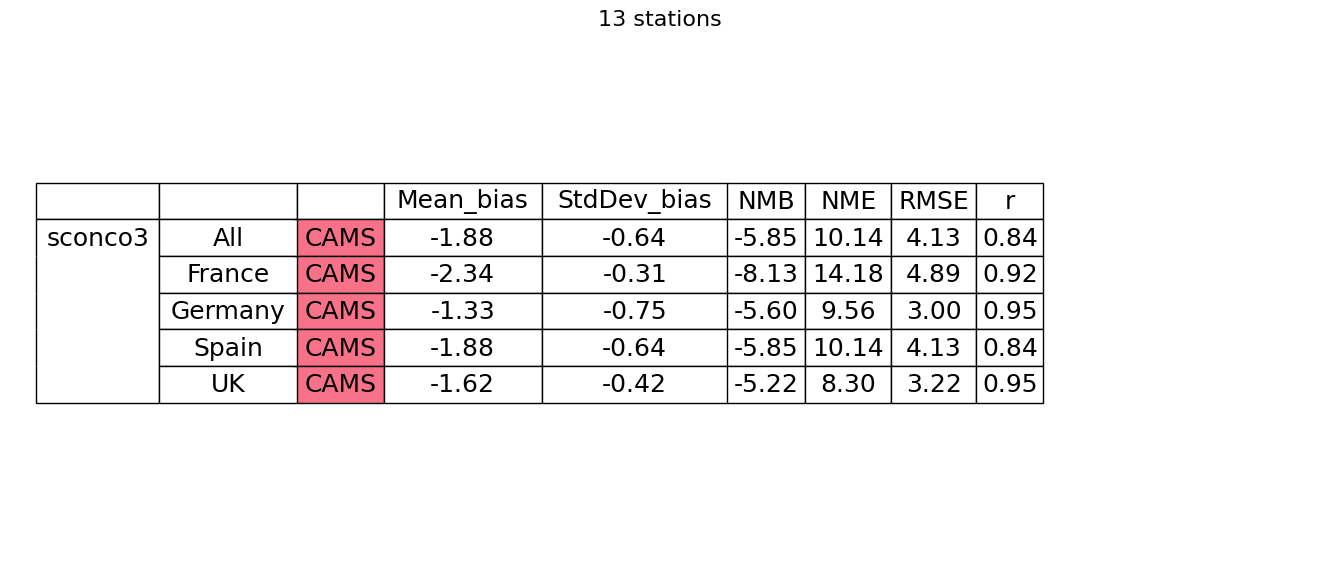

In [38]:
# make a statsummary plot
provi.plot('statsummary', multispecies=True, bias=True)

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Saving statsummary_bias_multispecies figure to /Users/denebowdalo/provi_master/plots/statsummary_bias_multispecies.png


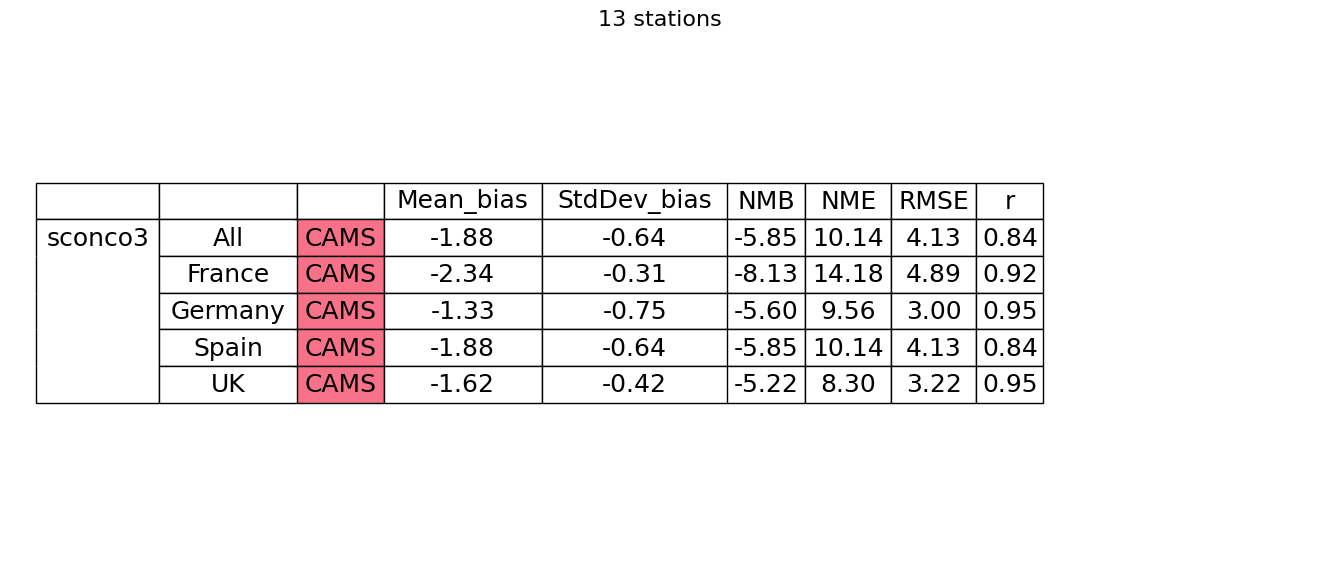

In [39]:
# save a statsummary plot
provi.plot('statsummary', multispecies=True, bias=True, save=True)

Resetting data filters to when class was initialised, loading LOCAL·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·France subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Germany subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·UK subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading LOCAL·Spain subsection filters.
Filtering data


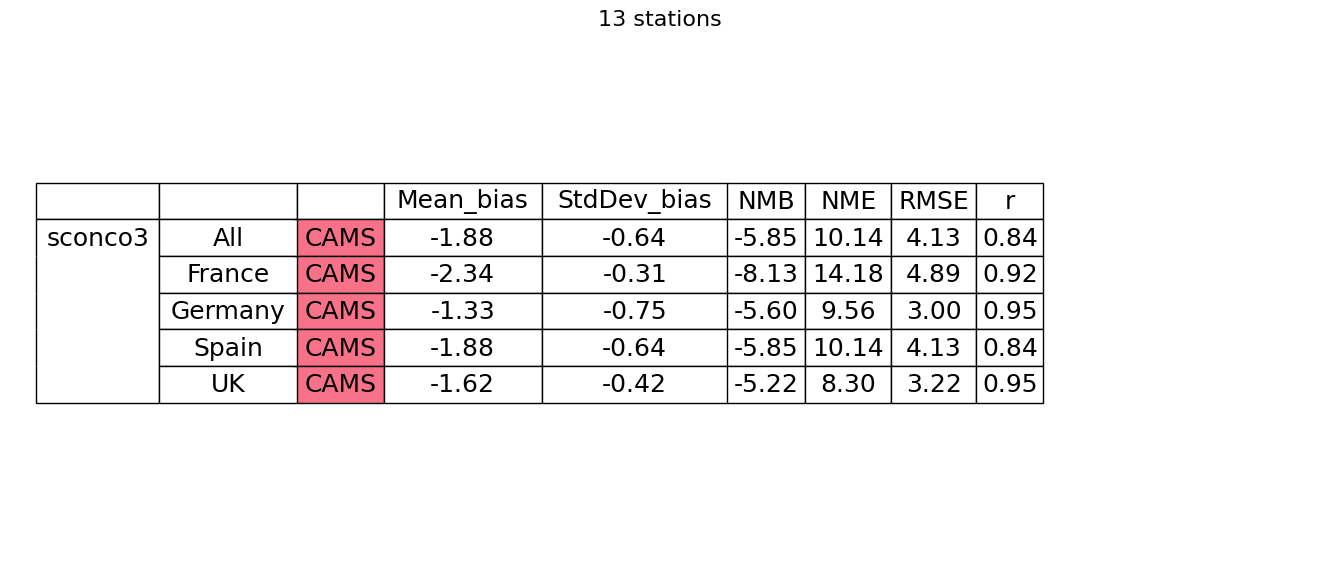

In [40]:
# return a statsummary plot
fig = provi.plot('statsummary', multispecies=True, bias=True, return_plot=True)

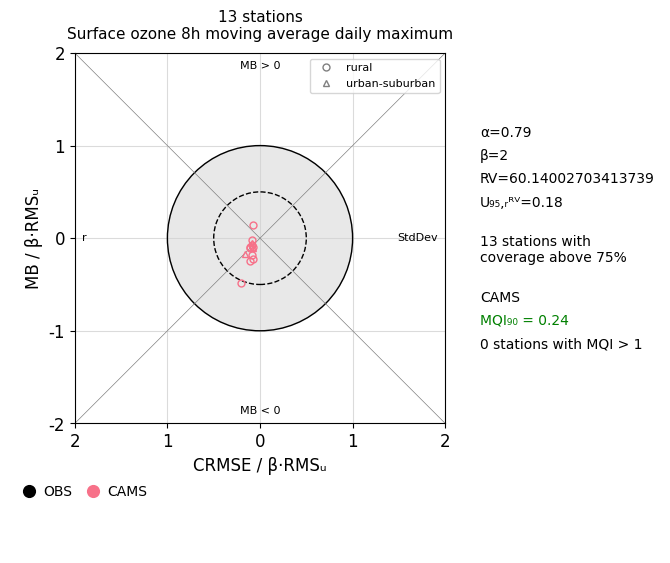

In [41]:
# make a fairmode-target plot
provi.plot('fairmode-target', annotate=True)

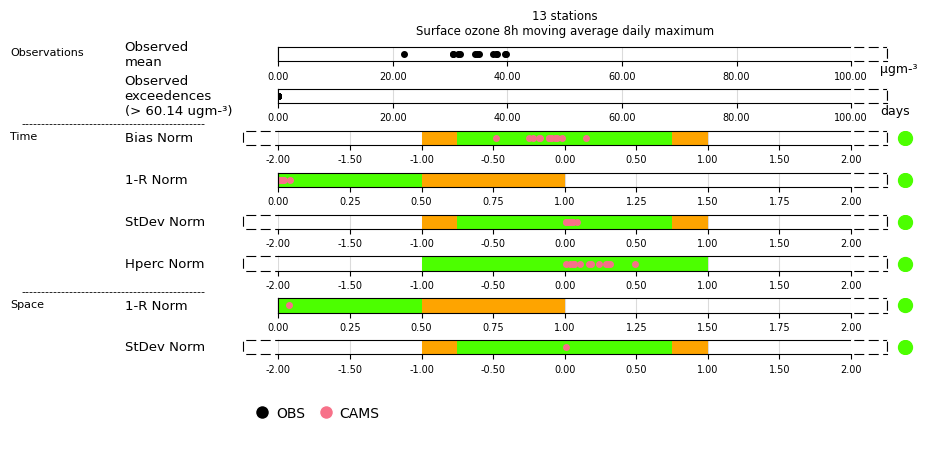

In [42]:
# make a fairmode-statsummary plot
provi.plot('fairmode-statsummary')

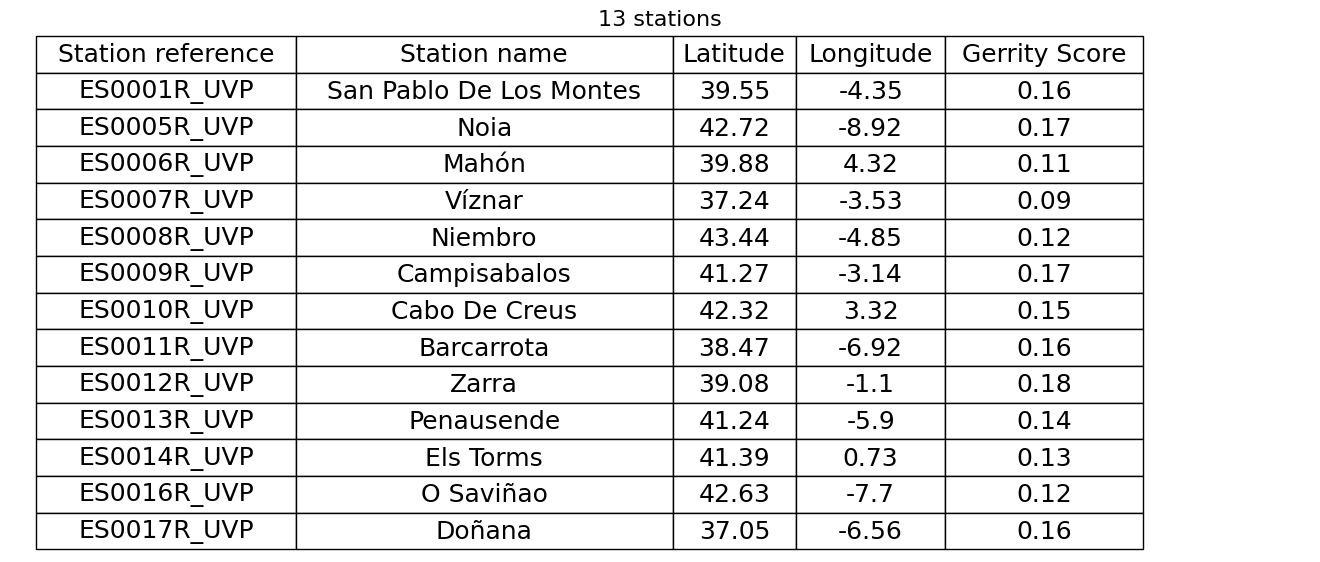

In [43]:
# make a contingencytable plot
provi.plot('contingencytable', gerrity=True)

Filtering data


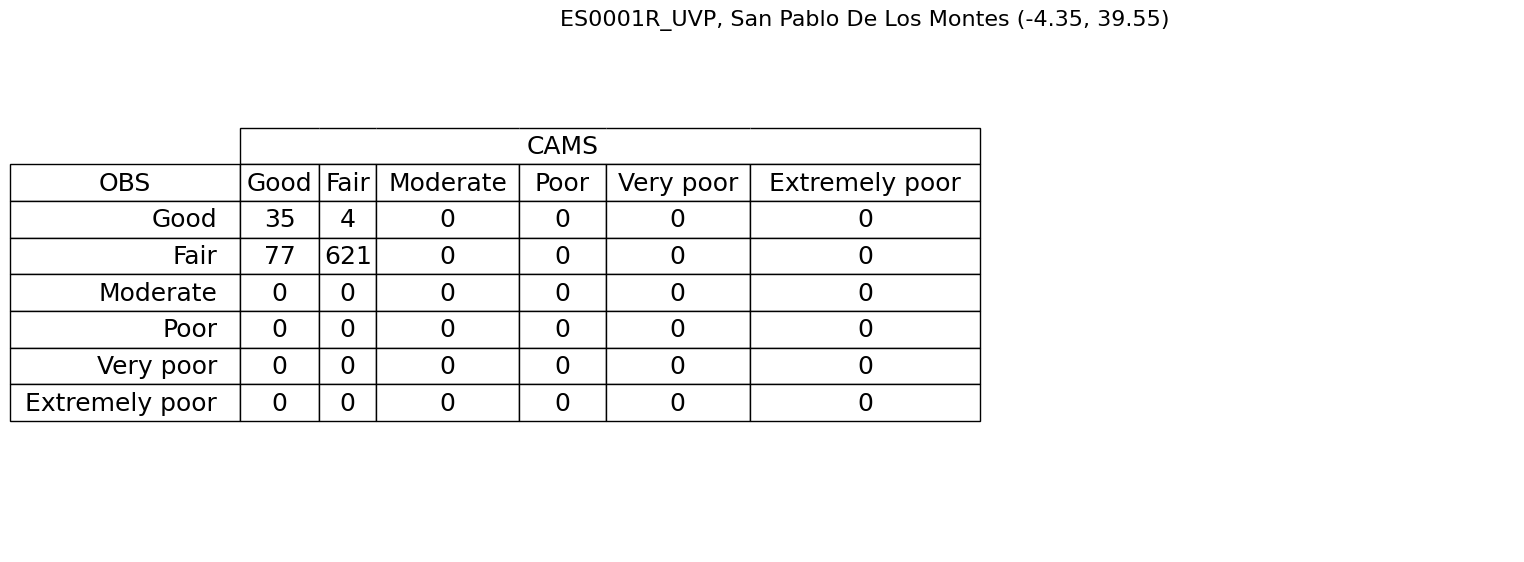

In [44]:
# make a contingencytable plot
provi.filter_station('ES0001R_UVP')
provi.plot('contingencytable')